### Base de dados fetch_20newsgroups

In [ ]:
from sklearn.datasets import

raw_documents = fetch_20newsgroups(subset='all', return_X_y=True)
documents = raw_documents[0]

In [ ]:
#https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer(stop_words='english')
count_vect.fit(documents)
len(count_vect.vocabulary_)

129796

In [ ]:
print(f" quant palavras da base completa {sum([doc[1] for doc in count_vect.vocabulary_.items()])}")


 quant palavras da base completa 15042537975


Base de treinamento

In [ ]:
raw_documents_train = fetch_20newsgroups(subset='train', return_X_y=True)
documents = raw_documents_train[0]
count_vect = CountVectorizer(stop_words='english')
count_vect.fit(documents)
print(f"Temos {len(documents)} documentos e {sum([doc[1] for doc in count_vect.vocabulary_.items()])} palavras")
print(f"{documents[0]}")

'could enlighten car saw day'

Temos 11314 documentos e 8423435910 palavras
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







'could enlighten car saw day'

In [ ]:
print(f"{documents[13]}")
# "SPACE STATION REDESIGN"
# vectorize 6324
# Tf-idf 4307
# Lsa 6256


# "cursor distortion driver"

# 1000 1993apr14 aaron


From: dbm0000@tm0006.lerc.nasa.gov (David B. Mckissock)
Subject: Re: Space Station Redesign, JSC Alternative #4
Organization: NASA Lewis Research Center / Cleveland, Ohio
Lines: 102
Distribution: world
NNTP-Posting-Host: tm0006.lerc.nasa.gov
News-Software: VAX/VMS VNEWS 1.41    

In article <1993Apr23.184732.1105@aio.jsc.nasa.gov>, kjenks@gothamcity.jsc.nasa.gov writes...

   {Description of "External Tank" option for SSF redesign deleted}

>Mark proposed this design at Joe Shea's committee in Crystal City,
>and he reports that he was warmly received.  However, the rumors
>I hear say that a design based on a wingless Space Shuttle Orbiter
>seems more likely.

Yo Ken, let's keep on-top of things! Both the "External Tank" and
"Wingless Orbiter" options have been deleted from the SSF redesign
options list. Today's (4/23) edition of the New York Times reports
that O'Connor told the panel that some redesign proposals have
been dropped, such as using the "giant external fuel tanks used
in la

In [ ]:
for i, (token, count) in enumerate(count_vect.vocabulary_.items()):
  print(f"{token} - {count}")
  if i ==20:
    break

lerxst - 75215
wam - 122887
umd - 118013
edu - 50455
thing - 114439
subject - 111094
car - 37722
nntp - 87451
posting - 94962
host - 63970
rac3 - 98748
organization - 90192
university - 118714
maryland - 79519
college - 40939
park - 91885
lines - 75888
15 - 4605
wondering - 124627
enlighten - 51714
saw - 104609


Remover stopword e tokinize

In [ ]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
nltk.download('stopwords')
list_stop = stopwords.words('english')

documents_tokens = []
for doc in documents:
    documents_tokens.append(
        [token.lower() for token in word_tokenize(doc, language='english') if not token.lower()  in list_stop]
    )

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
documents_tokens[0][:]

[':',
 'v064mb9k',
 '@',
 'ubvmsd.cc.buffalo.edu',
 '(',
 'neil',
 'b.',
 'gandler',
 ')',
 'subject',
 ':',
 'need',
 'info',
 '88-89',
 'bonneville',
 'organization',
 ':',
 'university',
 'buffalo',
 'lines',
 ':',
 '10',
 'news-software',
 ':',
 'vax/vms',
 'vnews',
 '1.41',
 'nntp-posting-host',
 ':',
 'ubvmsd.cc.buffalo.edu',
 'little',
 'confused',
 'models',
 '88-89',
 'bonnevilles',
 '.',
 'heard',
 'le',
 'se',
 'lse',
 'sse',
 'ssei',
 '.',
 'could',
 'someone',
 'tell',
 'differences',
 'far',
 'features',
 'performance',
 '.',
 'also',
 'curious',
 'know',
 'book',
 'value',
 'prefereably',
 '89',
 'model',
 '.',
 'much',
 'less',
 'book',
 'value',
 'usually',
 'get',
 '.',
 'words',
 'much',
 'demand',
 'time',
 'year',
 '.',
 'heard',
 'mid-spring',
 'early',
 'summer',
 'best',
 'time',
 'buy',
 '.',
 'neil',
 'gandler']

In [ ]:
pre_processed_documents = [' '.join(doc) for doc in documents_tokens]
print(pre_processed_documents[0])

: lerxst @ wam.umd.edu ( 's thing ) subject : car ! ? nntp-posting-host : rac3.wam.umd.edu organization : university maryland , college park lines : 15 wondering anyone could enlighten car saw day . 2-door sports car , looked late 60s/ early 70s . called bricklin . doors really small . addition , front bumper separate rest body . know . anyone tellme model name , engine specs , years production , car made , history , whatever info funky looking car , please e-mail . thanks , - il -- -- brought neighborhood lerxst -- --


**max_df : float in range [0.0, 1.0] or int, default=1.0**
> When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

**min_df : float in range [0.0, 1.0] or int, default=1**  
> When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold. This value is also called cut-off in the literature. If float, the parameter represents a proportion of documents, integer absolute counts. This parameter is ignored if vocabulary is not None.

**max_features : int, default=None**
> If not None, build a vocabulary that only consider the top max_features ordered by term frequency across the corpus. Otherwise, all features are used.

In [ ]:
count_vect = CountVectorizer(stop_words=None, min_df=0.005, max_df=0.5, max_features=3000)
count_vect.fit(pre_processed_documents)
print(f"Temos {len(count_vect.vocabulary_)} documentos e {sum([doc[1] for doc in count_vect.vocabulary_.items()])} palavras")

Temos 3000 documentos e 4498500 palavras


In [ ]:
sorted(count_vect.vocabulary_.items(), reverse=False)

[('00', np.int64(0)),
 ('000', np.int64(1)),
 ('01', np.int64(2)),
 ('02', np.int64(3)),
 ('03', np.int64(4)),
 ('04', np.int64(5)),
 ('05', np.int64(6)),
 ('06', np.int64(7)),
 ('07', np.int64(8)),
 ('08', np.int64(9)),
 ('09', np.int64(10)),
 ('10', np.int64(11)),
 ('100', np.int64(12)),
 ('1000', np.int64(13)),
 ('11', np.int64(14)),
 ('12', np.int64(15)),
 ('120', np.int64(16)),
 ('128', np.int64(17)),
 ('129', np.int64(18)),
 ('13', np.int64(19)),
 ('130', np.int64(20)),
 ('14', np.int64(21)),
 ('140', np.int64(22)),
 ('145', np.int64(23)),
 ('15', np.int64(24)),
 ('150', np.int64(25)),
 ('16', np.int64(26)),
 ('17', np.int64(27)),
 ('18', np.int64(28)),
 ('19', np.int64(29)),
 ('1920', np.int64(30)),
 ('1982', np.int64(31)),
 ('1983', np.int64(32)),
 ('1988', np.int64(33)),
 ('1989', np.int64(34)),
 ('1990', np.int64(35)),
 ('1991', np.int64(36)),
 ('1992', np.int64(37)),
 ('1993', np.int64(38)),
 ('1993apr14', np.int64(39)),
 ('1993apr15', np.int64(40)),
 ('1993apr16', np.int64(


## Extração de caracteristicas TF-IDF

In [ ]:
X = count_vect.transform(pre_processed_documents)
print(X[0, :])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 46 stored elements and shape (1, 3000)>
  Coords	Values
  (0, 24)	1
  (0, 192)	1
  (0, 270)	2
  (0, 443)	1
  (0, 474)	1
  (0, 504)	1
  (0, 519)	5
  (0, 633)	1
  (0, 721)	1
  (0, 783)	1
  (0, 890)	1
  (0, 915)	1
  (0, 959)	1
  (0, 1159)	1
  (0, 1299)	1
  (0, 1321)	1
  (0, 1353)	1
  (0, 1382)	1
  (0, 1495)	1
  (0, 1515)	1
  (0, 1597)	1
  (0, 1598)	1
  (0, 1619)	1
  (0, 1622)	1
  (0, 1649)	1
  (0, 1728)	1
  (0, 1782)	1
  (0, 1827)	1
  (0, 1943)	1
  (0, 2027)	1
  (0, 2059)	1
  (0, 2105)	1
  (0, 2190)	1
  (0, 2263)	1
  (0, 2334)	1
  (0, 2395)	1
  (0, 2478)	1
  (0, 2522)	1
  (0, 2533)	1
  (0, 2682)	1
  (0, 2686)	1
  (0, 2792)	2
  (0, 2808)	1
  (0, 2923)	1
  (0, 2958)	1
  (0, 2989)	1


In [ ]:
X.shape

(11314, 3000)

In [ ]:
count_vect.get_feature_names_out()[2999]

'zuma'

In [ ]:
#aplicando tf-idf
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X)
X_tfidf = tfidf_transformer.transform(X)
print(X_tfidf[0,:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 46 stored elements and shape (1, 3000)>
  Coords	Values
  (0, 24)	0.09234754632066343
  (0, 192)	0.1390457785143126
  (0, 270)	0.14989138318707085
  (0, 443)	0.127110434650142
  (0, 474)	0.13640716294440422
  (0, 504)	0.1007498472700871
  (0, 519)	0.5561016156858933
  (0, 633)	0.11376634577743777
  (0, 721)	0.07023802597049966
  (0, 783)	0.09656323767497248
  (0, 890)	0.14604767859873727
  (0, 915)	0.12326216094127047
  (0, 959)	0.14166885906957918
  (0, 1159)	0.1260975383931907
  (0, 1299)	0.12166122324732649
  (0, 1321)	0.05165387681610273
  (0, 1353)	0.14270091291453757
  (0, 1382)	0.10665100904570135
  (0, 1495)	0.0624267234982807
  (0, 1515)	0.13443984135436093
  (0, 1597)	0.13177725667555193
  (0, 1598)	0.1007498472700871
  (0, 1619)	0.09244678619309032
  (0, 1622)	0.087349310106115
  (0, 1649)	0.15948412830129957
  (0, 1728)	0.128976488723853
  (0, 1782)	0.10208609682673085
  (0, 1827)	0.05201981773154459
  (0, 1943)	

In [ ]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 821451 stored elements and shape (11314, 3000)>

## Modelagem de tópicos SVD

In [ ]:
from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation

svd = TruncatedSVD(n_components=600, n_iter=10 , random_state=0)
svd.fit(X_tfidf)
print('Total de variabilidade explicada: ', sum(svd.explained_variance_ratio_))

Total de variabilidade explicada:  0.5915579985294027


## Matrizes do LSA

A melhor forma de visualizar termos importantes é usando um componente gráfico, aqui vamos gerar a matriz e depois plotar em um heatmap 3D

In [ ]:
import numpy as np

# topics x tokens
V = svd.components_
print(f"matriz SVD {V.shape}")

# m -> tokens mais importantes
# k -> tópico (0 - 599)
m = 20
k = 0
tokens_t_k = np.argsort(V[k,:])[-m:][::-1]
print('ids: ', tokens_t_k)
print(f'Tópico {k}: ', count_vect.get_feature_names_out()[tokens_t_k])

matriz SVD (600, 3000)
ids:  [ 639 2972 1885  317  497 1565 1968 2808 1495 2059 1196 1321 1827 2688
 1218  721  752 2710 2825 1211]
Tópico 0:  ['com' 'would' 'one' 'article' 'ca' 'like' 'people' 'university' 'know'
 'posting' 'get' 'host' 'nntp' 'think' 'good' 'could' 'cs' 'time' 'use'
 'god']


Tópico 0:  ['com' 'would' 'one' 'article' 'ca' 'like' 'people' 'university' 'know'
 'posting' 'get' 'host' 'nntp' 'think' 'good' 'cs' 'could' 'time' 'use'
 'god']

 Tópico 57:  ['umd' 'eng' 'stratus' 'org' 'hp' 'msg' 'cramer' 'computer' 'sw' 'ai'
 'stanford' 'optilink' 'scsi' 'cdt' 'maryland' 'uga' 'god' 'purdue'
 'college' 'mit']

 Tópico 20:  ['ca' 'car' 'bnr' 'bike' 'toronto' 'canada' 'henry' '__' '___' 'sgi' 'org'
 'keith' 'bc' 'caltech' 'armenian' 'israel' 'livesey' 'sun' 'key'
 'armenians']

Matriz U do SVD
OU seja Documentos x Tópicos

In [ ]:
X_lsa = svd.transform(X_tfidf)
X_lsa.shape

(11314, 600)

In [ ]:
# top 3 tópicos mais importantes do documento d
t = 5
d = 35
topics_t_d = np.argsort(X_lsa[d,:])[-t:][::-1]
print(pre_processed_documents[d])
print('Tópicos: ', topics_t_d)
print(X_lsa[d,topics_t_d])

print('\nDescrição do documento ', d, ':')
m = 15
for topic in topics_t_d:
  tokens_t_k = np.argsort(V[topic,:])[-m:][::-1]
  print(f'Tópico {topic}: ', count_vect.get_feature_names_out()[tokens_t_k])

: dchhabra @ stpl.ists.ca ( deepak chhabra ) subject : : goalie masks nntp-posting-host : stpl.ists.ca organization : solar terresterial physics laboratory , ists lines : 21 article < 120666 @ netnews.upenn.edu > kkeller @ mail.sas.upenn.edu ( keith keller ) writes : > vote goes john vanbiesbrouck . mask skyline new york > city , sides bunch bees ( beezer ) . looks > really sharp . funny mention ; one time hnic cherry pointed vanbiesbrouck 's mask . _hated_ . think said something effect : '' see ? great last year ; goes gets dopey mask ca n't stop beachball ! '' may may take cherry seriously , cracked heard . think ed belfour current best mask nhl btw . also like moog 's , 'll give fuhr 's new one honourable mention , although n't seen closely yet ( looked good distance ! ) . 's also neat chevaldae 's detroit ; call `` chevy '' two checkered flags painted top auto race .
Tópicos:  [ 0 62 66 20 80]
[0.24335541 0.11764392 0.0952706  0.09064918 0.08598868]

Descrição do documento  35 :
Tó

In [ ]:
X_lsa_copy = X_lsa.copy()

# Selecionando os 't' tópicos mais relevantes para toda a base
X_lsa_copy.sort()
X_lsa_copy = X_lsa_copy[:, :]
X_lsa_copy.shape

(11314, 600)

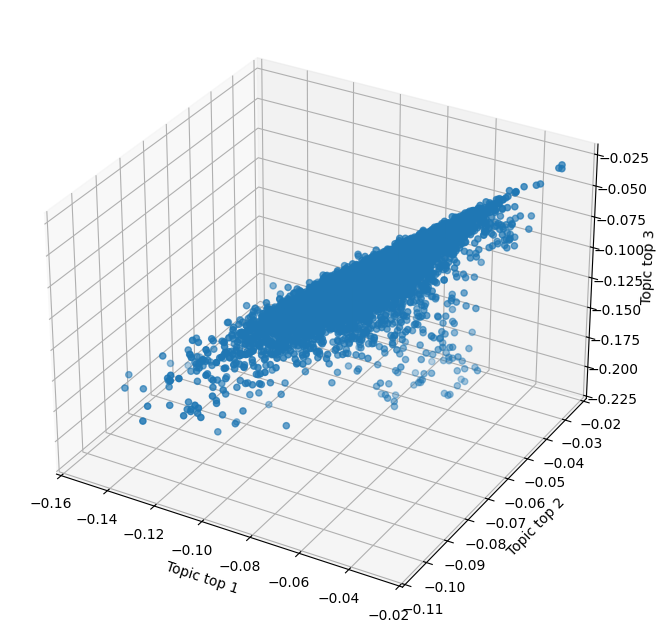

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_lsa_copy[:,7], X_lsa_copy[:,13], X_lsa_copy[:,3], marker='o')

ax.set_xlabel('Topic top 1')
ax.set_ylabel('Topic top 2')
ax.set_zlabel('Topic top 3')

plt.show()

Aplicando o PCA

(11314, 3)


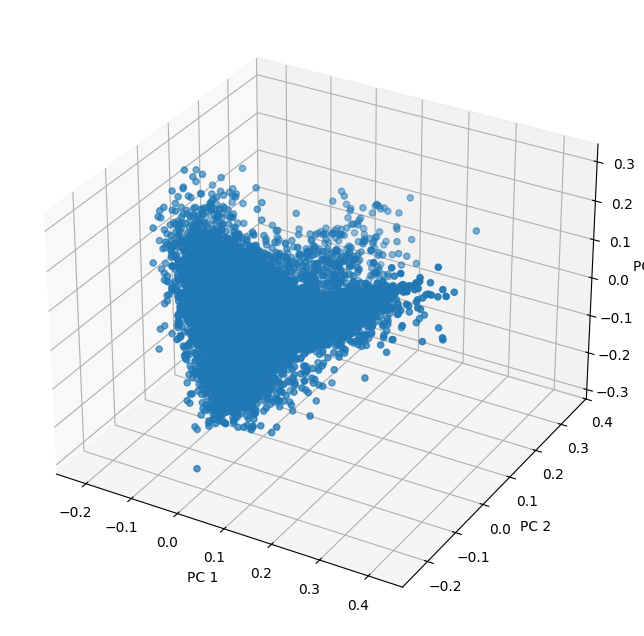

In [ ]:
from sklearn.decomposition import PCA

X_lsa_3d = PCA(n_components=3, random_state=0).fit_transform(X_lsa)
print(X_lsa_3d.shape)

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_lsa_3d[:,0], X_lsa_3d[:,1], X_lsa_3d[:,2], marker='o')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')

plt.show()

In [ ]:
X_lsa_3d[0,0]

np.float64(-0.033330487585564395)

## Transformando o texto de uma query em vetores de características


In [ ]:
final_list_stop_words = list_stop
query = 'SPACE STATION REDESIGN'
# query = "1000 1993apr14 aaron"

query_tokens = [token for token in word_tokenize(query, language='english') if not token in final_list_stop_words]
print(query_tokens)
pre_processed_query = ' '.join(query_tokens)
print(pre_processed_query)

# Extração de características de contagem
X_query = count_vect.transform([pre_processed_query])
print('1 - etapa de extração de características')
print(X_query)

# Extração de características de frequência TF-IDF
X_tfidf_query = tfidf_transformer.transform(X_query)
print('2 - etapa de extração de características')
print(X_tfidf_query)

# Extração dos embeddings da query
X_lsa_query = svd.transform(X_tfidf_query)
print('3 - etapa de extração de características')
print(X_lsa_query)

['SPACE', 'STATION', 'REDESIGN']
SPACE STATION REDESIGN
1 - etapa de extração de características
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (1, 3000)>
  Coords	Values
  (0, 2515)	1
  (0, 2560)	1
2 - etapa de extração de características
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 3000)>
  Coords	Values
  (0, 2515)	0.6167537491354083
  (0, 2560)	0.7871561553639899
3 - etapa de extração de características
[[ 3.58619042e-02 -1.71760445e-02 -3.69517113e-03 -2.62570447e-02
  -7.97668565e-02  6.55643757e-03  1.99104633e-01 -9.32561126e-02
  -2.49131867e-02 -1.77890850e-02 -1.82152945e-02 -8.96937748e-03
   1.46015949e-03 -2.08813015e-02  3.93660545e-02  2.77115244e-02
   5.07761832e-03 -5.58901057e-02 -3.33238040e-03 -2.84609800e-02
  -1.08006638e-02  2.06949687e-02 -5.73166649e-02  4.65929333e-02
   2.09088755e-02  1.66957125e-01  2.08762859e-02  3.63130724e-02
   1.14215655e-02  5.59467001e-02 -6.

## Calcular a distância da query para os textos

### Usando LSA

In [ ]:
from sklearn.metrics import pairwise_distances
import numpy

# Matriz de vetores dos documentos -> X_lsa
# Vetor da query -> X_lsa_query
# Recuperar k documentos mais relevantes a query
k = 17

ouput_distances = pairwise_distances(X_lsa, X_lsa_query, metric='euclidean')[:,0]
sorted_distances = list(sorted(ouput_distances))[:k]
sorted_indexes = list(numpy.argsort(ouput_distances)[:k])

print(query)
i=0
for id_doc, dist in zip(sorted_indexes, sorted_distances):
    # i = i+1
    # if id_doc == 13:
      print('Doc id: ', id_doc, ' Distance: ', dist, "i ",i)

SPACE STATION REDESIGN
Doc id:  6256  Distance:  0.5116683938256519 i  0
Doc id:  7545  Distance:  0.5282878033505575 i  0
Doc id:  2912  Distance:  0.5668983484959953 i  0
Doc id:  4307  Distance:  0.5691533738614221 i  0
Doc id:  10086  Distance:  0.6277423624218431 i  0
Doc id:  10165  Distance:  0.6346618112651374 i  0
Doc id:  2950  Distance:  0.6432171476440809 i  0
Doc id:  9986  Distance:  0.6749443309878835 i  0
Doc id:  10851  Distance:  0.6780445416882211 i  0
Doc id:  2837  Distance:  0.7059140971729309 i  0
Doc id:  1288  Distance:  0.7127086179158174 i  0
Doc id:  9323  Distance:  0.7184715207969767 i  0
Doc id:  9812  Distance:  0.7292244594620435 i  0
Doc id:  7448  Distance:  0.7381049702038419 i  0
Doc id:  10839  Distance:  0.7453261960431371 i  0
Doc id:  6707  Distance:  0.7534283614506195 i  0
Doc id:  13  Distance:  0.7625359439469729 i  0


### Usando TF-IDF

In [ ]:
k = 17

ouput_distances = pairwise_distances(X_tfidf, X_tfidf_query, metric='euclidean')[:,0]
sorted_distances = list(sorted(ouput_distances))[:k]
sorted_indexes = list(numpy.argsort(ouput_distances)[:k])

print('Distância usando TF-IDF')
print(query)
for id_doc, dist in zip(sorted_indexes, sorted_distances):
    print('Doc id: ', id_doc, ' Distance: ', dist)
    # if 1000 == id_doc:


Distância usando TF-IDF
SPACE STATION REDESIGN
Doc id:  4307  Distance:  0.8858635561452819
Doc id:  6256  Distance:  0.8952876255981287
Doc id:  10086  Distance:  0.8999493943120588
Doc id:  7545  Distance:  0.9192460025317053
Doc id:  2912  Distance:  0.9227450413113046
Doc id:  1288  Distance:  0.9793650545525847
Doc id:  9323  Distance:  1.0057184519465592
Doc id:  10165  Distance:  1.0059671776850467
Doc id:  9986  Distance:  1.016228114099651
Doc id:  1399  Distance:  1.0503438843081985
Doc id:  10839  Distance:  1.0885184587905627
Doc id:  5315  Distance:  1.0995937071435327
Doc id:  2837  Distance:  1.1047246889903517
Doc id:  2800  Distance:  1.1107413711474179
Doc id:  9812  Distance:  1.1126622648941698
Doc id:  4504  Distance:  1.1275236134583235
Doc id:  2550  Distance:  1.131101103633777


### Usando Vectorizer

In [ ]:
k = 17

ouput_distances = pairwise_distances(X, X_query, metric='euclidean')[:,0]
sorted_distances = list(sorted(ouput_distances))[:k]
sorted_indexes = list(numpy.argsort(ouput_distances)[:k])

print('Distância usando Count Vectorizer')
print(query)
for id_doc, dist in zip(sorted_indexes, sorted_distances):
    print('Doc id: ', id_doc, ' Distance: ', dist)

Distância usando Count Vectorizer
SPACE STATION REDESIGN
Doc id:  6324  Distance:  2.23606797749979
Doc id:  5345  Distance:  2.8284271247461903
Doc id:  9573  Distance:  2.8284271247461903
Doc id:  5639  Distance:  2.8284271247461903
Doc id:  9622  Distance:  2.8284271247461903
Doc id:  9989  Distance:  3.0
Doc id:  800  Distance:  3.0
Doc id:  493  Distance:  3.1622776601683795
Doc id:  9533  Distance:  3.1622776601683795
Doc id:  6530  Distance:  3.1622776601683795
Doc id:  6506  Distance:  3.1622776601683795
Doc id:  5123  Distance:  3.1622776601683795
Doc id:  1636  Distance:  3.1622776601683795
Doc id:  2865  Distance:  3.1622776601683795
Doc id:  4003  Distance:  3.1622776601683795
Doc id:  3472  Distance:  3.1622776601683795
Doc id:  8602  Distance:  3.1622776601683795


## Classificador de texto
### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_tfidf = RandomForestClassifier(n_estimators=500, n_jobs=-1, max_features=5, max_depth=5, oob_score=True, verbose=2, random_state=0)

### Treinando com TF-IDF

In [ ]:
y = raw_documents_train[1]
print(y.shape)
rf_clf_tfidf.fit(X_tfidf, y)

(11314,)
building tree 1 of 500
building tree 2 of 500
building tree 3 of 500
building tree 4 of 500
building tree 5 of 500
building tree 6 of 500
building tree 7 of 500
building tree 8 of 500
building tree 9 of 500
building tree 10 of 500
building tree 11 of 500


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    0.1s


building tree 12 of 500
building tree 13 of 500
building tree 14 of 500
building tree 15 of 500
building tree 16 of 500
building tree 17 of 500
building tree 18 of 500
building tree 19 of 500
building tree 20 of 500
building tree 21 of 500
building tree 22 of 500
building tree 23 of 500
building tree 24 of 500
building tree 25 of 500
building tree 26 of 500
building tree 27 of 500
building tree 28 of 500
building tree 29 of 500
building tree 30 of 500
building tree 31 of 500
building tree 32 of 500
building tree 33 of 500
building tree 34 of 500
building tree 35 of 500
building tree 36 of 500
building tree 37 of 500
building tree 38 of 500
building tree 39 of 500
building tree 40 of 500
building tree 41 of 500
building tree 42 of 500
building tree 43 of 500
building tree 44 of 500
building tree 45 of 500
building tree 46 of 500
building tree 47 of 500
building tree 48 of 500
building tree 49 of 500
building tree 50 of 500
building tree 51 of 500
building tree 52 of 500
building tree 53

[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:    0.6s


building tree 179 of 500
building tree 180 of 500
building tree 181 of 500
building tree 182 of 500
building tree 183 of 500
building tree 184 of 500
building tree 185 of 500
building tree 186 of 500
building tree 187 of 500
building tree 188 of 500
building tree 189 of 500
building tree 190 of 500
building tree 191 of 500
building tree 192 of 500
building tree 193 of 500
building tree 194 of 500
building tree 195 of 500
building tree 196 of 500
building tree 197 of 500
building tree 198 of 500
building tree 199 of 500
building tree 200 of 500
building tree 201 of 500
building tree 202 of 500
building tree 203 of 500
building tree 204 of 500
building tree 205 of 500
building tree 206 of 500
building tree 207 of 500
building tree 208 of 500
building tree 209 of 500
building tree 210 of 500
building tree 211 of 500
building tree 212 of 500
building tree 213 of 500
building tree 214 of 500
building tree 215 of 500
building tree 216 of 500
building tree 217 of 500
building tree 218 of 500


[Parallel(n_jobs=-1)]: Done 361 tasks      | elapsed:    1.4s


building tree 389 of 500
building tree 390 of 500
building tree 391 of 500
building tree 392 of 500
building tree 393 of 500
building tree 394 of 500
building tree 395 of 500
building tree 396 of 500
building tree 397 of 500
building tree 398 of 500
building tree 399 of 500
building tree 400 of 500
building tree 401 of 500
building tree 402 of 500
building tree 403 of 500
building tree 404 of 500
building tree 405 of 500
building tree 406 of 500
building tree 407 of 500
building tree 408 of 500
building tree 409 of 500
building tree 410 of 500
building tree 411 of 500
building tree 412 of 500
building tree 413 of 500
building tree 414 of 500
building tree 415 of 500
building tree 416 of 500
building tree 417 of 500
building tree 418 of 500
building tree 419 of 500
building tree 420 of 500
building tree 421 of 500
building tree 422 of 500
building tree 423 of 500
building tree 424 of 500
building tree 425 of 500
building tree 426 of 500
building tree 427 of 500
building tree 428 of 500


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    1.9s finished


RandomForestClassifier(max_depth=5, max_features=5, n_estimators=500, n_jobs=-1,
                       oob_score=True, random_state=0, verbose=2)

In [ ]:
acuracia = rf_clf_tfidf.score(X_tfidf, y)
print('Média da acurácia das classes: ', acuracia)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:    1.3s


Média da acurácia das classes:  0.7620646986035001


[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    1.6s finished


## Treinando uma RandomForest com as features LSA (tópicos) dos documentos

In [ ]:
rf_clf_lsa = RandomForestClassifier(n_estimators=500, n_jobs=-1, max_features=5, max_depth=5, oob_score=True, verbose=2, random_state=0)
rf_clf_lsa.fit(X_lsa, y)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 500building tree 2 of 500

building tree 3 of 500
building tree 4 of 500
building tree 5 of 500
building tree 6 of 500
building tree 7 of 500
building tree 8 of 500
building tree 9 of 500building tree 10 of 500

building tree 11 of 500
building tree 12 of 500
building tree 13 of 500
building tree 14 of 500
building tree 15 of 500
building tree 16 of 500
building tree 17 of 500
building tree 18 of 500
building tree 19 of 500
building tree 20 of 500
building tree 21 of 500
building tree 22 of 500
building tree 23 of 500
building tree 24 of 500
building tree 25 of 500
building tree 26 of 500
building tree 27 of 500
building tree 28 of 500
building tree 29 of 500
building tree 30 of 500
building tree 31 of 500
building tree 32 of 500
building tree 33 of 500
building tree 34 of 500
building tree 35 of 500
building tree 36 of 500
building tree 37 of 500
building tree 38 of 500
building tree 39 of 500
building tree 40 of 500
building tree 41 of 500
building tree 42 of 500
b

[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    1.2s


building tree 47 of 500
building tree 48 of 500
building tree 49 of 500
building tree 50 of 500
building tree 51 of 500
building tree 52 of 500
building tree 53 of 500
building tree 54 of 500
building tree 55 of 500
building tree 56 of 500
building tree 57 of 500
building tree 58 of 500
building tree 59 of 500
building tree 60 of 500
building tree 61 of 500
building tree 62 of 500
building tree 63 of 500
building tree 64 of 500
building tree 65 of 500
building tree 66 of 500
building tree 67 of 500
building tree 68 of 500
building tree 69 of 500
building tree 70 of 500
building tree 71 of 500
building tree 72 of 500
building tree 73 of 500
building tree 74 of 500
building tree 75 of 500
building tree 76 of 500
building tree 77 of 500
building tree 78 of 500
building tree 79 of 500
building tree 80 of 500
building tree 81 of 500
building tree 82 of 500
building tree 83 of 500
building tree 84 of 500
building tree 85 of 500
building tree 86 of 500
building tree 87 of 500
building tree 88

[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:    6.9s


building tree 165 of 500
building tree 166 of 500
building tree 167 of 500
building tree 168 of 500
building tree 169 of 500
building tree 170 of 500
building tree 171 of 500
building tree 172 of 500
building tree 173 of 500
building tree 174 of 500
building tree 175 of 500
building tree 176 of 500
building tree 177 of 500
building tree 178 of 500
building tree 179 of 500
building tree 180 of 500
building tree 181 of 500
building tree 182 of 500
building tree 183 of 500
building tree 184 of 500
building tree 185 of 500
building tree 186 of 500
building tree 187 of 500
building tree 188 of 500
building tree 189 of 500
building tree 190 of 500
building tree 191 of 500
building tree 192 of 500
building tree 193 of 500
building tree 194 of 500
building tree 195 of 500
building tree 196 of 500
building tree 197 of 500
building tree 198 of 500
building tree 199 of 500
building tree 200 of 500
building tree 201 of 500
building tree 202 of 500
building tree 203 of 500
building tree 204 of 500


[Parallel(n_jobs=-1)]: Done 361 tasks      | elapsed:   13.2s


building tree 366 of 500
building tree 367 of 500
building tree 368 of 500
building tree 369 of 500
building tree 370 of 500
building tree 371 of 500
building tree 372 of 500
building tree 373 of 500
building tree 374 of 500
building tree 375 of 500
building tree 376 of 500
building tree 377 of 500
building tree 378 of 500
building tree 379 of 500
building tree 380 of 500
building tree 381 of 500
building tree 382 of 500
building tree 383 of 500
building tree 384 of 500
building tree 385 of 500
building tree 386 of 500
building tree 387 of 500
building tree 388 of 500
building tree 389 of 500
building tree 390 of 500
building tree 391 of 500
building tree 392 of 500
building tree 393 of 500
building tree 394 of 500
building tree 395 of 500
building tree 396 of 500
building tree 397 of 500
building tree 398 of 500
building tree 399 of 500
building tree 400 of 500
building tree 401 of 500
building tree 402 of 500
building tree 403 of 500
building tree 404 of 500
building tree 405 of 500


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.3s finished


RandomForestClassifier(max_depth=5, max_features=5, n_estimators=500, n_jobs=-1,
                       oob_score=True, random_state=0, verbose=2)

In [ ]:
print('Média da acurácia das classes: ', rf_clf_lsa.score(X_lsa, y))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:    0.5s


Média da acurácia das classes:  0.7649814389252254


[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.7s finished


# Avaliação do classificador com a base teste


In [ ]:
# Obter a base de teste
raw_documents_test = fetch_20newsgroups(subset='test', return_X_y=True)

test_documents, y_test = raw_documents_test

# Pre processamento
documents_tokens = []
for doc in test_documents:
    documents_tokens.append(
        [token.lower() for token in word_tokenize(doc, language='english') if not token.lower() in final_list_stop_words]
    )
pre_processed_documents_test = [' '.join(doc) for doc in documents_tokens]

# Extração de características de contagem
X_test = count_vect.transform(pre_processed_documents_test)
print('1a etapa de extração de características')
print(X_test.shape)

# Extração de características de frequência TF-IDF
X_tfidf_test = tfidf_transformer.transform(X_test)
print('2a etapa de extração de características')
print(X_tfidf_test.shape)

# Extração dos embeddings
X_lsa_test = svd.transform(X_tfidf_test)
print('3a etapa de extração de características')
print(X_lsa_test.shape)

1a etapa de extração de características
(7532, 3000)
2a etapa de extração de características
(7532, 3000)
3a etapa de extração de características
(7532, 600)


In [ ]:
print('[TF-IDF] Média da acurácia das classes: ', rf_clf_tfidf.score(X_tfidf_test, y_test))
print('[LSA features] Média da acurácia das classes: ', rf_clf_lsa.score(X_lsa_test, y_test))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.2s


[TF-IDF] Média da acurácia das classes:  0.6779075942644716
[LSA features] Média da acurácia das classes:  0.592671269251195


[Parallel(n_jobs=2)]: Done 361 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.6s finished
